In [1]:
import numpy as np
import pandas as pd
import sys
import phate
sys.path.append("../utils")
sys.path.append("../training")
import matplotlib.pyplot as plt
import matplotlib
import os
from sklearn.neighbors import NearestNeighbors

from umap import UMAP
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from geometric_features import get_path_sig, get_path_sigs
import iisignature
from stage_dataset import StageDataset
from tqdm.auto import tqdm
from umap import UMAP


from scipy.spatial.distance import cdist
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif
from sklearn.feature_selection import mutual_info_classif
from sklearn.feature_selection import chi2
from sklearn.ensemble import RandomForestClassifier
from stats_utils import RunningStats, prfcm, disp_cm
import torch
from sklearn.metrics import normalized_mutual_info_score
from sklearn.metrics import rand_score
from tslearn.metrics import dtw

tqdm.pandas()

In [2]:
# hyperparameters
PHASES = ["tPB2", "tPNa", "tPNf", "t2", "t3", "t4", "t5", "t6", "t7", "t8", "t9+", "tM", "tSB", "tB", "tEB"]
model_name = "convlstm_final-2026-07-13"
TIME_OFFSET = 0.0
PCA_DIM = 8
path_sig_depth = 2
GRADE_COLORS = {"A":(0,1,0), "B":(1,1,0), "C":(1,0,0), "NA":(0.5,0.5,0.5)}
grade = "TE" # "TE"

In [3]:
# load latents and metadata
metadata_df = pd.read_csv(os.path.join("latents",f"{model_name}.csv"))
latents = np.load(os.path.join("latents",f"{model_name}.npy"))
metadata_df = metadata_df.fillna('NA')
id_set = set(metadata_df["embryo_id"].unique())
for p in ["tPNf", "tM"]:
    ids = metadata_df[metadata_df["phase"]==p]["embryo_id"].unique()
    id_set &= set(ids)
    print(p, ": ",len(ids))
id_list = list(id_set)
stripped_phases = ["tPNf","t2", "t3", "t4", "t5", "t6", "t7", "t8", "t9+", "tM", ]
mask = metadata_df["phase"].isin(stripped_phases) & metadata_df["embryo_id"].isin(id_list)
#"tPB2", "tPNa",  "tSB", "tB"
# only graded 
latents = latents[mask]
metadata_df = metadata_df[mask]
latents_df = pd.DataFrame(latents, columns=[f"z_{i}" for i in range(latents.shape[1])], index=metadata_df.index)
pca_cols = [f"pca_{i}" for i in range(PCA_DIM)]
pca = PCA(n_components=PCA_DIM)
pca_latents = pca.fit_transform(StandardScaler().fit_transform(latents))
print(pca.explained_variance_ratio_)
pca_latents_df = pd.DataFrame(pca_latents, columns=pca_cols, index=metadata_df.index)
df = pd.concat([metadata_df, latents_df, pca_latents_df], axis=1)



tPNf :  693
tM :  555
[0.22587463 0.10143861 0.05593139 0.04729208 0.04556353 0.04037918
 0.03184653 0.0295997 ]


In [4]:
ps_cols = [f"path_sig_{i}" for i in range(len(iisignature.basis(iisignature.prepare(PCA_DIM+1, path_sig_depth))))]

def path_sig_agg(group):
    pca_traj = group[pca_cols].to_numpy()
    path_sig = get_path_sig(pca_traj, path_sig_depth, time_offsets=TIME_OFFSET)
    out_df = pd.DataFrame(path_sig[None, :], columns = ps_cols)
    
    out_df["grade"] = [group.iloc[0][grade]]
    return out_df
path_sig_df = df.groupby("embryo_id").progress_apply(path_sig_agg).reset_index()
print(len(path_sig_df))


  0%|          | 0/547 [00:00<?, ?it/s]

547


/home/jenslundsgaard/ivf/.venv/lib/python3.12/site-packages/tqdm/std.py:917: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return getattr(df, df_function)(wrapper, **kwargs)


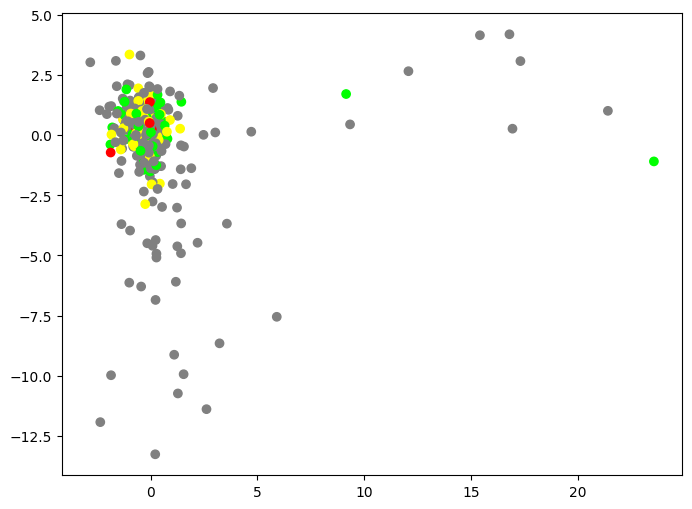

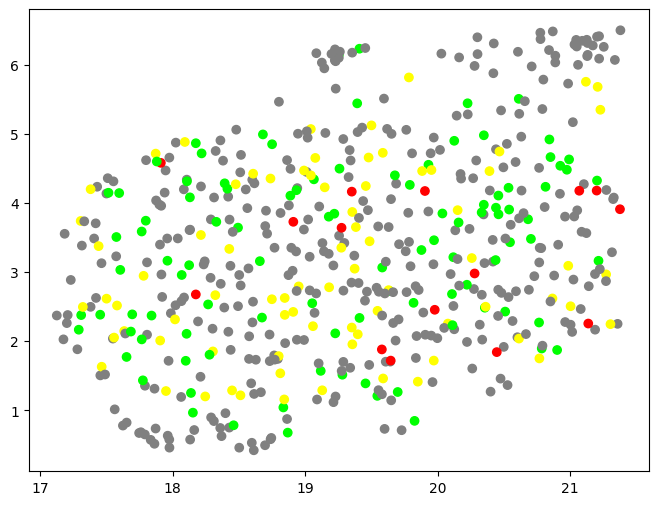

Calculating PHATE...
  Running PHATE on 547 observations and 45 variables.
  Calculating graph and diffusion operator...
    Calculating KNN search...
    Calculated KNN search in 0.03 seconds.
    Calculating affinities...
    Calculated affinities in 0.99 seconds.
  Calculated graph and diffusion operator in 1.02 seconds.
  Calculating optimal t...
    Automatically selected t = 11
  Calculated optimal t in 0.11 seconds.
  Calculating diffusion potential...
  Calculated diffusion potential in 0.06 seconds.
  Calculating metric MDS...
    SGD-MDS may not have converged: stress changed by -2.2% in final iterations. Consider increasing n_iter or adjusting learning_rate.
  Calculated metric MDS in 1.87 seconds.
Calculated PHATE in 3.08 seconds.


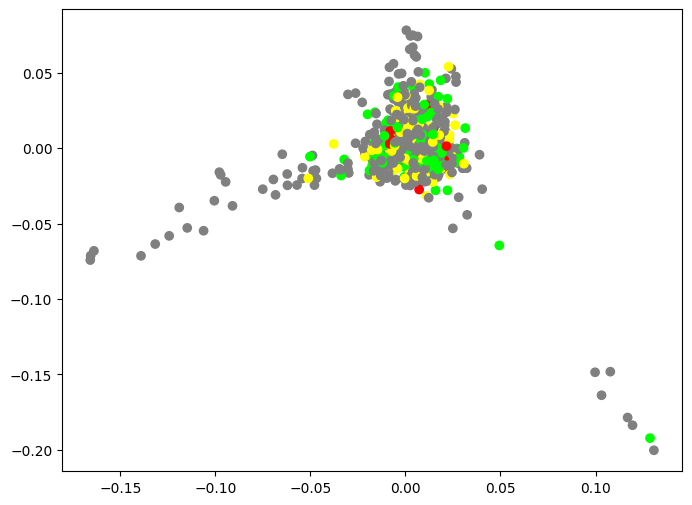

In [5]:
%matplotlib inline
GRADES = ["A","B", "C","NA"]
path_sig_df["grade_indices"]  = [GRADES.index(p) for p in path_sig_df['grade'].to_list()]
PS_PCA_SIZE = 2

normed_path_sigs = StandardScaler().fit_transform(path_sig_df[ps_cols].to_numpy())
visual_ps = PCA(n_components=2).fit_transform(normed_path_sigs)
visual_ps_grade_indices = path_sig_df["grade_indices"].to_list()
visual_ps_grades = [GRADES[g] for g in visual_ps_grade_indices]
visual_ps_colors = [GRADE_COLORS[g] for g in visual_ps_grades]
fig, ax = plt.subplots(figsize=(8,6))#, subplot_kw={"projection":"3d"})
ax.scatter(visual_ps[:,0], visual_ps[:,1], c=visual_ps_colors)#, visual_ps[:,2]
plt.show()
plt.close(fig)
plt.close()


normed_path_sigs = StandardScaler().fit_transform(path_sig_df[ps_cols].to_numpy())
visual_ps = UMAP(n_components=2).fit_transform(normed_path_sigs)
visual_ps_grade_indices = path_sig_df["grade_indices"].to_list()
visual_ps_grades = [GRADES[g] for g in visual_ps_grade_indices]
visual_ps_colors = [GRADE_COLORS[g] for g in visual_ps_grades]
fig, ax = plt.subplots(figsize=(8,6))#, subplot_kw={"projection":"3d"})
ax.scatter(visual_ps[:,0], visual_ps[:,1], c=visual_ps_colors)#, visual_ps[:,2]
plt.show()
plt.close(fig)
plt.close()

normed_path_sigs = StandardScaler().fit_transform(path_sig_df[ps_cols].to_numpy())
visual_ps = phate.PHATE(knn=5, decay=15, n_jobs=-2, verbose=True).fit_transform(normed_path_sigs)
visual_ps_grade_indices = path_sig_df["grade_indices"].to_list()
visual_ps_grades = [GRADES[g] for g in visual_ps_grade_indices]
visual_ps_colors = [GRADE_COLORS[g] for g in visual_ps_grades]
fig, ax = plt.subplots(figsize=(8,6))#, subplot_kw={"projection":"3d"})
ax.scatter(visual_ps[:,0], visual_ps[:,1], c=visual_ps_colors)#, visual_ps[:,2]
plt.show()
plt.close(fig)
plt.close()


In [6]:
def phase_ri(phase_df1, phase_df2, normalize=True):
    phase_df1 = phase_df1[phase_df1["stage"].isin(stripped_phases)] 
    phase_df2 = phase_df2[phase_df2["stage"].isin(stripped_phases)] 
    # normalize so that both have tPB2 start at 0 
    if(normalize):
        phase_df1.loc[:,["stage_begin", "stage_end"]] -= phase_df1.iloc[0]["stage_begin"]# first row is tPB2
        phase_df2.loc[:,["stage_begin", "stage_end"]] -= phase_df2.iloc[0]["stage_begin"]# first row is tPB2

    # turn into columns of index values
    new_column1 = []
    for index, row in phase_df1.iterrows():
        new_column1 += [StageDataset.PHASES.index(row["stage"])] * (row["stage_end"] - row["stage_begin"]+1)
        
    new_column2 = []
    for index, row in phase_df2.iterrows():
        new_column2 += [StageDataset.PHASES.index(row["stage"])] * (row["stage_end"] - row["stage_begin"]+1)
    
    new_column1 += [StageDataset.PHASES.index("post_phase")] * (max(len(new_column1),len(new_column2)) - len(new_column1))
    new_column2 += [StageDataset.PHASES.index("post_phase")] * (max(len(new_column1),len(new_column2)) - len(new_column2))
    assert len(new_column1) == len(new_column2), "new col lens are not the same"
    new_column1 = np.array(new_column1)
    new_column2 = np.array(new_column2)
    r_score = rand_score(new_column1, new_column2)
    # Normalize for whatever reason
    total = np.concatenate([new_column1, new_column2], axis=0)
    std_dev = total.std()
    mean = total.mean()
    new_column1 = (new_column1 - mean) / (std_dev + 1e-6)
    new_column2 = (new_column2 - mean) / (std_dev + 1e-6)
    alignment = dtw(new_column1, new_column2)
    return r_score, alignment
   
    

In [7]:
num_nbrs = 100
nbrs = NearestNeighbors(n_neighbors=num_nbrs, algorithm='ball_tree').fit(path_sig_df[ps_cols].to_numpy())
distances, indices = nbrs.kneighbors(path_sig_df[ps_cols].to_numpy())

print(indices)


limit = 1000

dists = []
r_scores = [RunningStats() for _ in range(num_nbrs)]
dtw_scores = [RunningStats() for _ in range(num_nbrs)]
for i1 in tqdm(range(path_sig_df[ps_cols].to_numpy().shape[0])):
    for nbr_idx, i2 in enumerate(indices[i1]):
        row1 = path_sig_df.iloc[i1]
        row2 = path_sig_df.iloc[i2]
        #print(row1["embryo_id"], f" {row1['grade']}", row2["embryo_id"], f" {row2['grade']}")
        
        phase_df1 = pd.read_csv(os.path.join("embryo_dataset_annotations",f"{row1["embryo_id"]}_phases.csv"), header=0) 
        phase_df1.columns = ["stage", "stage_begin","stage_end"]
        #print(phase_df1[phase_df1["stage"].isin(stripped_phases)])
        
        phase_df2 = pd.read_csv(os.path.join("embryo_dataset_annotations",f"{row2["embryo_id"]}_phases.csv"), header=0)
        phase_df2.columns = ["stage", "stage_begin","stage_end"]
        #print(phase_df2[phase_df2["stage"].isin(stripped_phases)])
        
        score, alignment = phase_ri(phase_df1, phase_df2)
        
        #print(f"rand score: {score}")
        #print(f"dtw score: {alignment}")
        
        r_scores[nbr_idx].push(score)
        dtw_scores[nbr_idx].push(alignment)
        #print("-"*50,"\n")
r_scores = np.array([[stat.mean, stat.std_dev] for stat in r_scores])
dtw_scores = np.array([[stat.mean, stat.std_dev] for stat in dtw_scores])
scores_df = pd.DataFrame(np.concatenate([r_scores, dtw_scores],axis=1), columns = ["rand", "rand_std_dev","dtw", "dtw_std_dev"])



[[  0 467 284 ... 465 142 510]
 [  1 206  55 ... 329 123 180]
 [  2 315 438 ...  20 152 513]
 ...
 [544 477 107 ... 204 519  95]
 [545 324 158 ... 133 241 423]
 [546 266 500 ... 466 104 208]]


  0%|          | 0/547 [00:00<?, ?it/s]

        rand  rand_std_dev       dtw  dtw_std_dev
0   1.000000      0.000000  0.000000     0.000000
1   0.845253      0.052135  9.013041     3.031705
2   0.841325      0.052974  9.277207     3.046500
3   0.843185      0.051311  9.097354     3.006043
4   0.843646      0.049657  9.216604     3.057391
..       ...           ...       ...          ...
95  0.838949      0.054116  9.320074     3.170536
96  0.841804      0.050981  9.158173     3.257728
97  0.842956      0.052471  9.302962     3.036606
98  0.844709      0.048963  9.301526     3.085719
99  0.839280      0.051248  9.332751     2.989138

[100 rows x 4 columns]


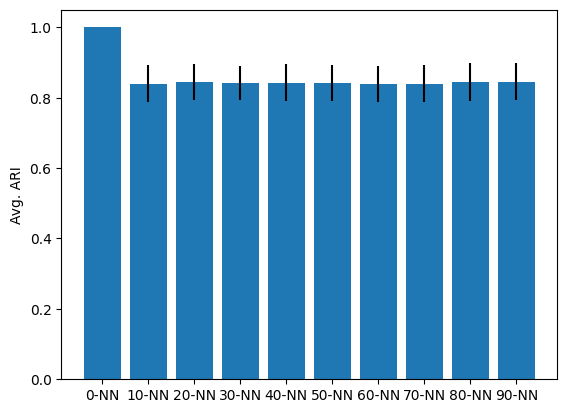

        rand  rand_std_dev       dtw  dtw_std_dev
0   1.000000      0.000000  0.000000     0.000000
1   0.845253      0.052135  9.013041     3.031705
2   0.841325      0.052974  9.277207     3.046500
3   0.843185      0.051311  9.097354     3.006043
4   0.843646      0.049657  9.216604     3.057391
..       ...           ...       ...          ...
95  0.838949      0.054116  9.320074     3.170536
96  0.841804      0.050981  9.158173     3.257728
97  0.842956      0.052471  9.302962     3.036606
98  0.844709      0.048963  9.301526     3.085719
99  0.839280      0.051248  9.332751     2.989138

[100 rows x 4 columns]


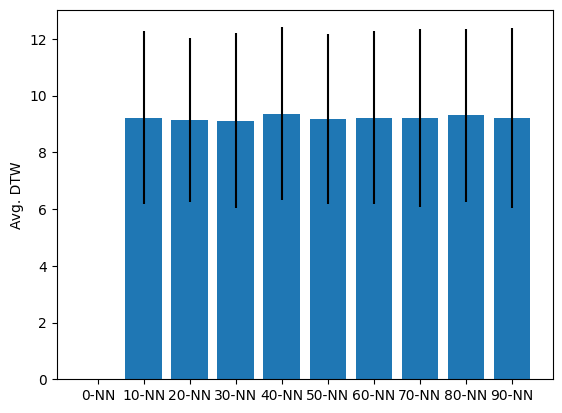

In [8]:
%matplotlib inline
print(scores_df)
fig, ax = plt.subplots()
labels = [f"{i}-NN" for i in range(num_nbrs)][::10]
scores = scores_df["rand"].to_numpy()[np.arange(num_nbrs) % 10 == 0]
errs = scores_df["rand_std_dev"].to_numpy()[np.arange(num_nbrs) % 10 == 0]
ax.bar(labels, scores, yerr=errs)
ax.set_ylabel('Avg. ARI')
plt.show()
print(scores_df)
fig, ax = plt.subplots()
labels = [f"{i}-NN" for i in range(num_nbrs)][::10]
scores = scores_df["dtw"].to_numpy()[np.arange(num_nbrs) % 10 == 0]
errs = scores_df["dtw_std_dev"].to_numpy()[np.arange(num_nbrs) % 10 == 0]
ax.bar(labels, scores, yerr=errs)
ax.set_ylabel('Avg. DTW')
plt.show()

In [9]:
embryos = metadata_df["embryo_id"].unique()
stats = RunningStats
for _ in range(100):
    np.random.shuffle(embryos)
    embryo1, embryo2 = embryos[:2]
    phase_df1 = pd.read_csv(os.path.join("embryo_dataset_annotations", f"{embryo1}_phases.csv"), header=0) 
    phase_df1.columns = ["stage", "stage_begin","stage_end"]
    print(phase_df1[phase_df1["stage"].isin(stripped_phases)])
    
    phase_df2 = pd.read_csv(os.path.join("embryo_dataset_annotations", f"{embryo2}_phases.csv"), header=0)
    phase_df2.columns = ["stage", "stage_begin","stage_end"]
    print(phase_df2[phase_df2["stage"].isin(stripped_phases)])
    score, alignment = phase_ri(phase_df1, phase_df2)
    print(f"rand score: {score}")
    stats.push(score)
    print(f"dtw score: {alignment}")
print(stats.mean, ", ", stats.std_dev)

   stage  stage_begin  stage_end
1   tPNf           87         98
2     t2           99        146
3     t3          147        148
4     t4          149        191
5     t5          192        193
6     t6          194        199
7     t7          200        201
8     t8          202        285
9    t9+          286        372
10    tM          373        428
  stage  stage_begin  stage_end
1  tPNf           62         67
2    t2           68        102
3    t4          103        133
4    t7          134        135
5    t8          136        187
6   t9+          188        251
7    tM          252        263
rand score: 0.8533381351717515


TypeError: RunningStats.push() missing 1 required positional argument: 'x'